In [1]:
%load_ext autoreload
%autoreload 2

# XTCAV Processing: Preprocessing

- get dark reference
- subtract background
- denoise
- normalize

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import psana

# XTCAV Processing Classes
from xtcav_processor import XTCAVProcessor
from xtcav_dark_reference import XTCAVDarkReference
get_datasource = lambda runnum: psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")

## Get Dark Reference

Setting up data run times...
Done.


Setting data source types...: 10322it [00:00, 25257.74it/s]                       


Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


Calculating dark reference: 100%|█████████▉| 999/1000 [00:03<00:00, 308.84it/s]



Maximum number of images processed



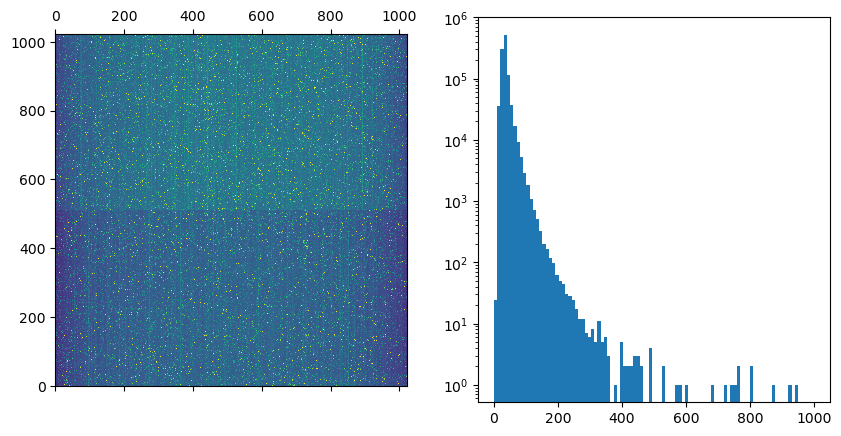

In [3]:
# Create XTCAVDarkReference class instance
xtdr = XTCAVDarkReference(get_datasource(215), max_shots=1000)

# Show the dark reference
xtdr.show(
    vrange = (0,1e2),
    bins = np.linspace(0,1000,100)
)

## Setup experiment run

Setting up data run times...
Done.


Setting data source types...: 22201it [00:00, 114543.44it/s]                     

Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>
Looping through the first 3 good events...


Showing good shot #1 at time index 170:


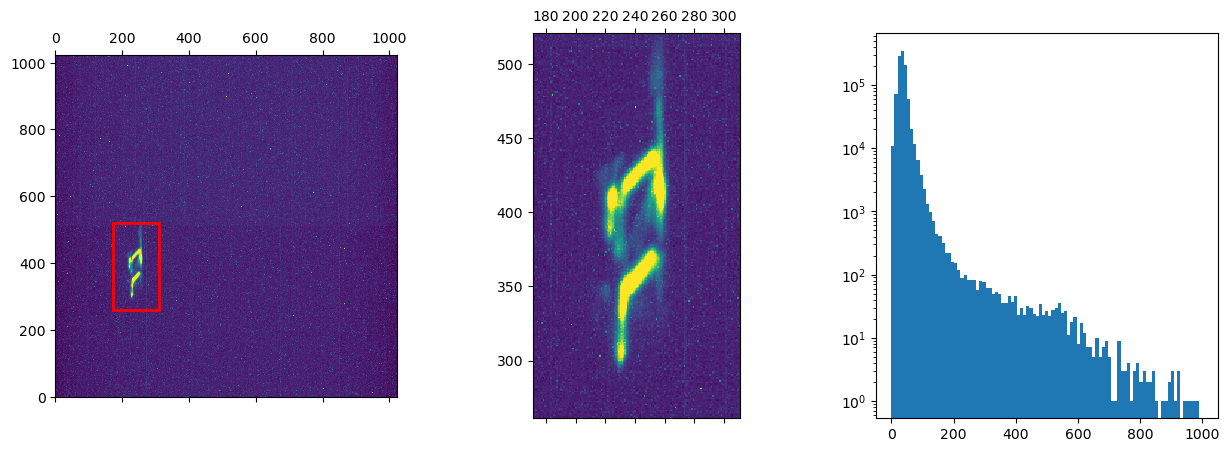

Showing good shot #2 at time index 171:


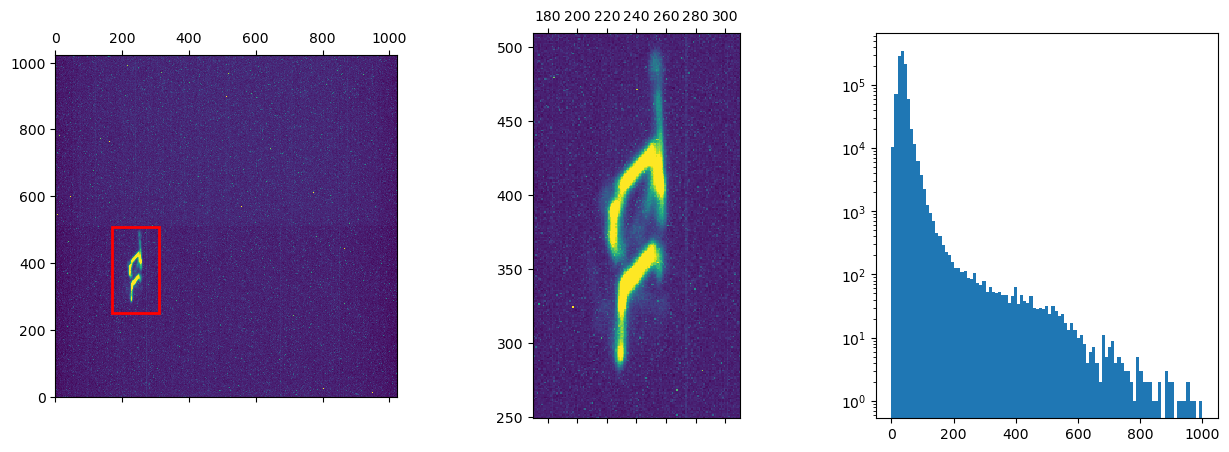

Showing good shot #3 at time index 172:


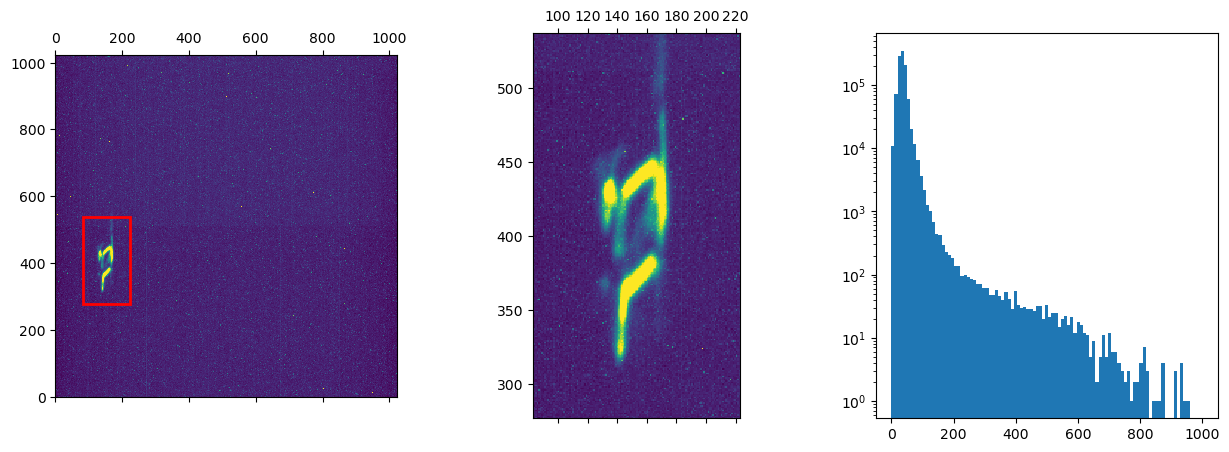

In [4]:
# Create the XTCAV processor
xtpr = XTCAVProcessor(get_datasource(216))

# Get and show some data

n_shots_show = 3
fov = 140,260

print(f"Looping through the first {n_shots_show} good events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(vrange=(0,350),bins=np.linspace(0,1000,100),fov=fov)

    # continue?
    if idx>=n_shots_show-1:
        break

In [8]:
# Resetting the shot iterator

# xtpr.reset_shot_iterator()
# xtpr._set_iteration_type('all')
# xtpr.reset_shot_iterator()

## Link & subtract background

In [5]:
xtpr.set_darkreference(xtdr)
#xtpr.set_darkreference(xtdr.dark_reference)   # Same as previous line

Looping through the first 3 good events...
Showing good shot #1 at time index 170:


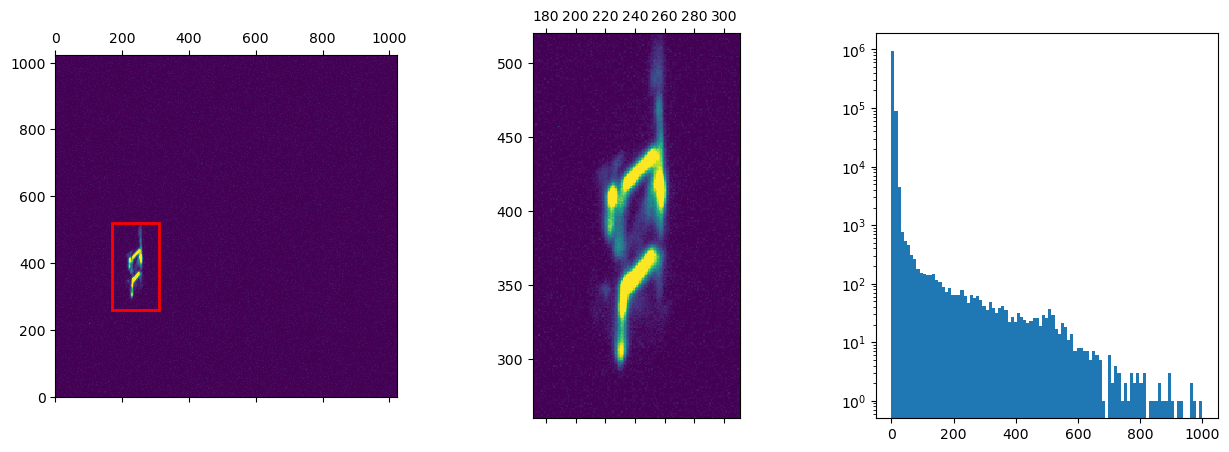

Showing good shot #2 at time index 171:


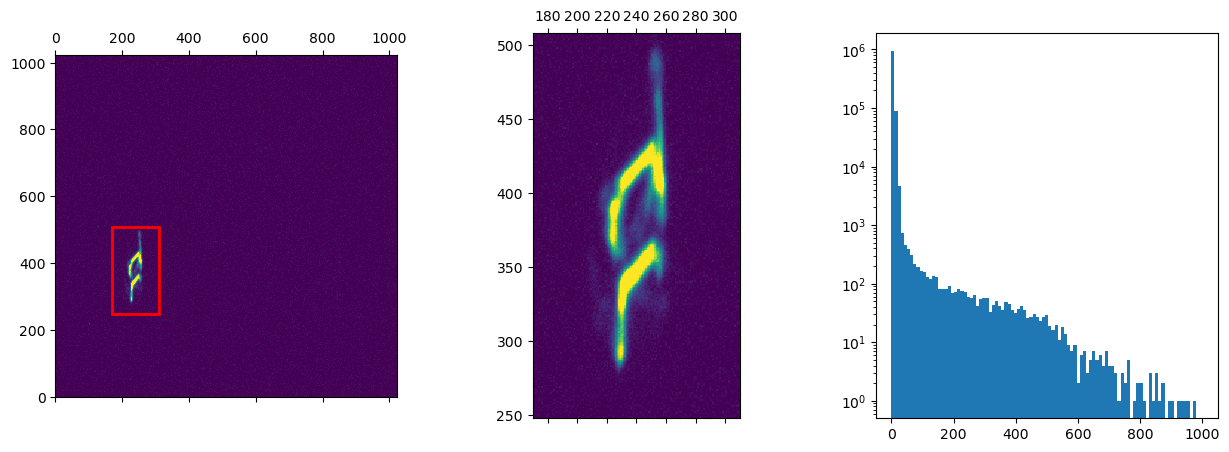

Showing good shot #3 at time index 172:


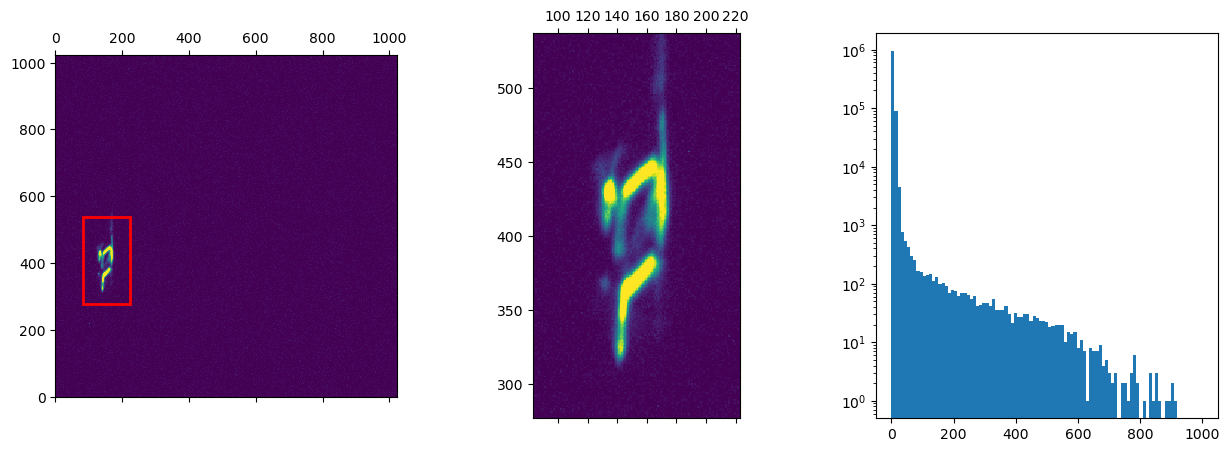

In [6]:
# Get and show some data with the background subtracted

xtpr.reset_shot_iterator()
n_shots_show = 3

print(f"Looping through the first {n_shots_show} good events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(vrange=(0,350),bins=np.linspace(0,1000,100),fov=fov,preprocess='bksb')

    # continue?
    if idx>=n_shots_show-1:
        break

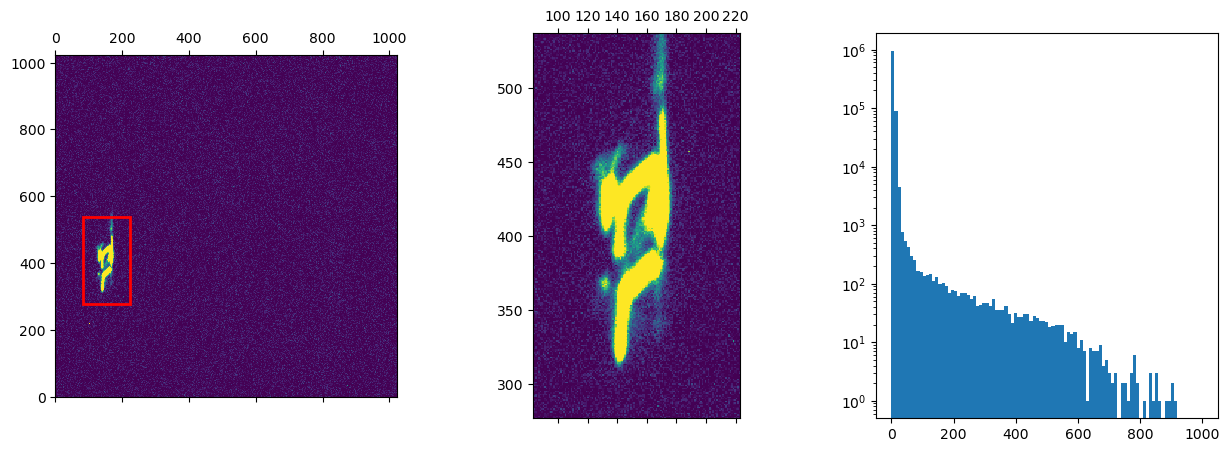

In [7]:
# Explicitly grab the background subtracted image frame

im = xtpr.get_frame_bksb_current()

xtpr.show_frame(
    im,
    #vrange=(0,350),
    #vrange=(0,200),
    vrange=(0,100),
    #vrange=(0,50),
    bins=np.linspace(0,1000,100),
    fov=fov
)

vmax = 350


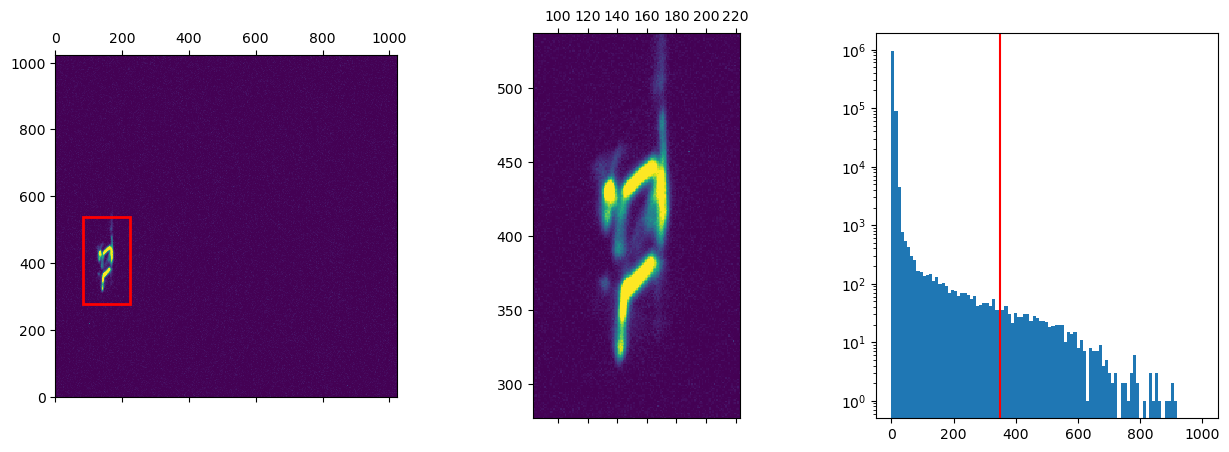

vmax = 200


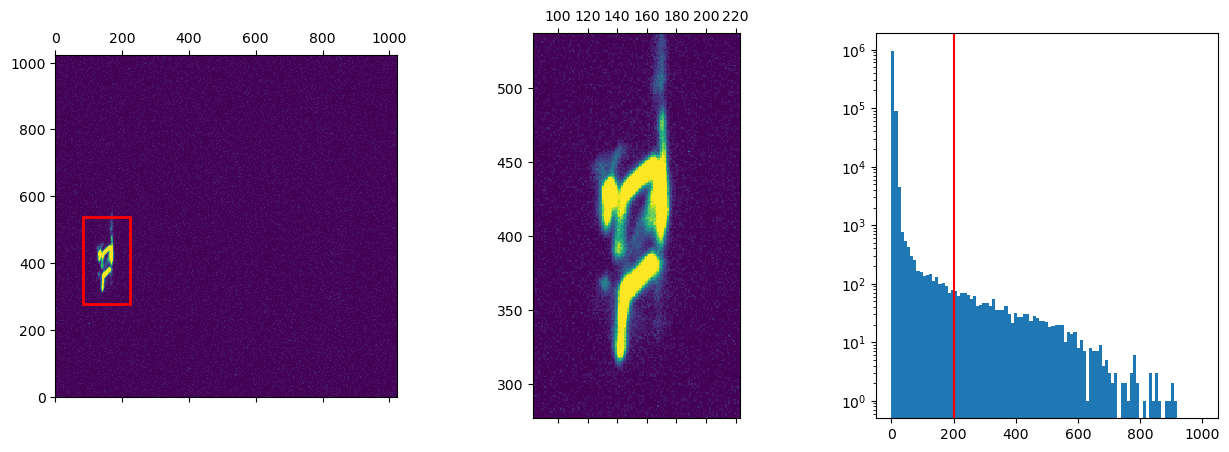

vmax = 100


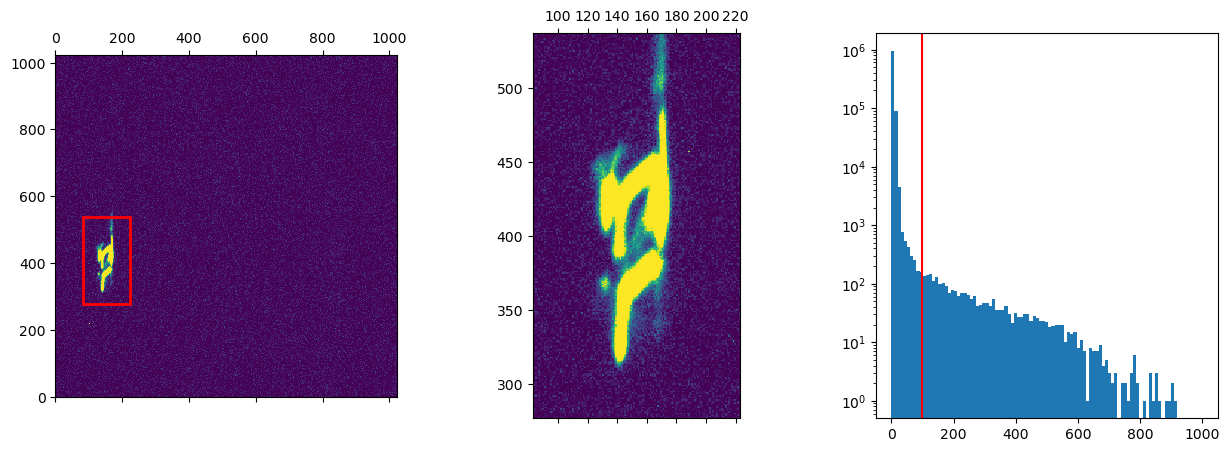

vmax = 50


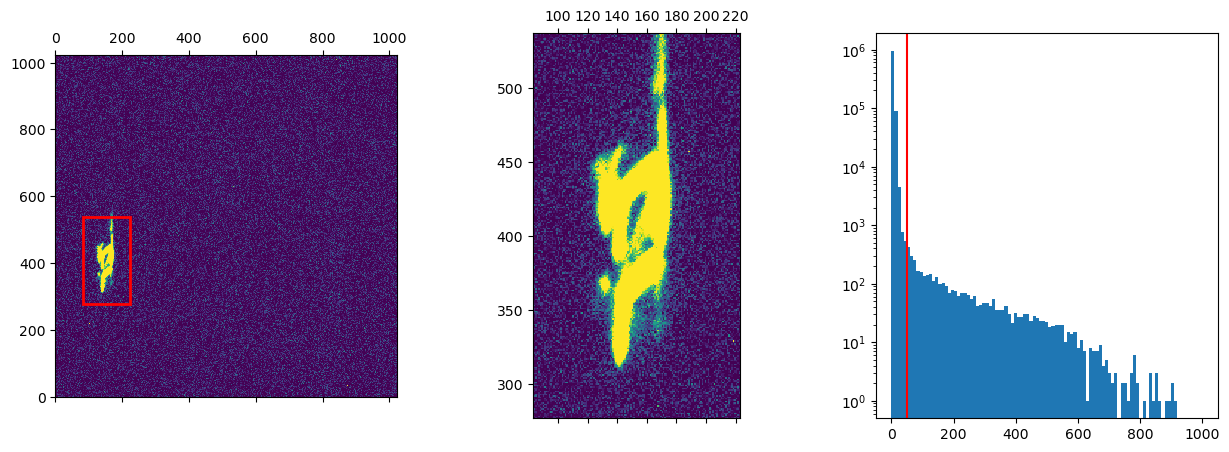

In [8]:
# Show at various histogram saturation points

for vmax in [350,200,100,50]:
    print(f'vmax = {vmax}')
    fig,axs = xtpr.show_frame(
        im,
        vrange=(0,vmax),
        bins=np.linspace(0,1000,100),
        fov=fov,
        returnfig=True
    )
    axs[2].vlines(vmax,0,axs[2].get_ylim()[1],color='r')
    plt.show()

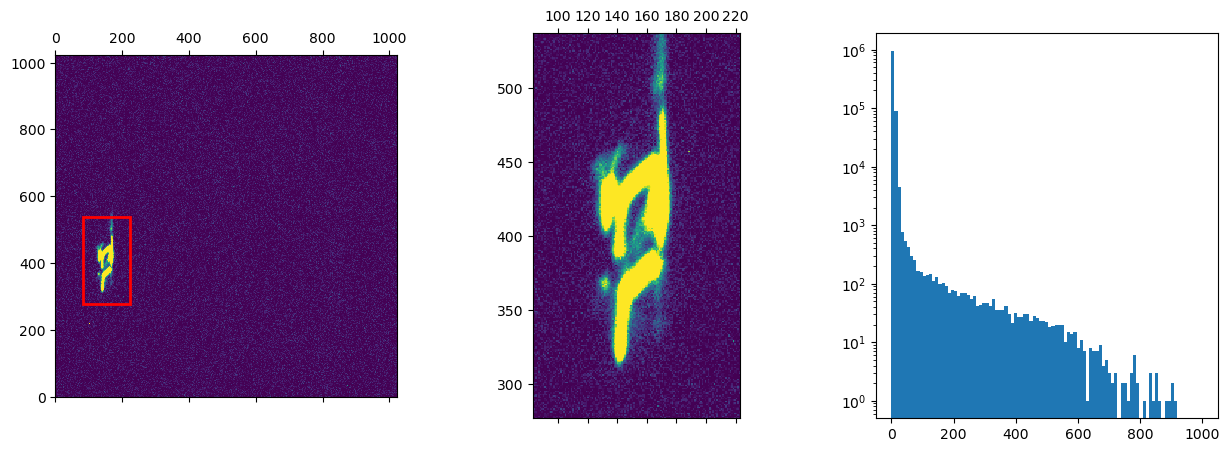

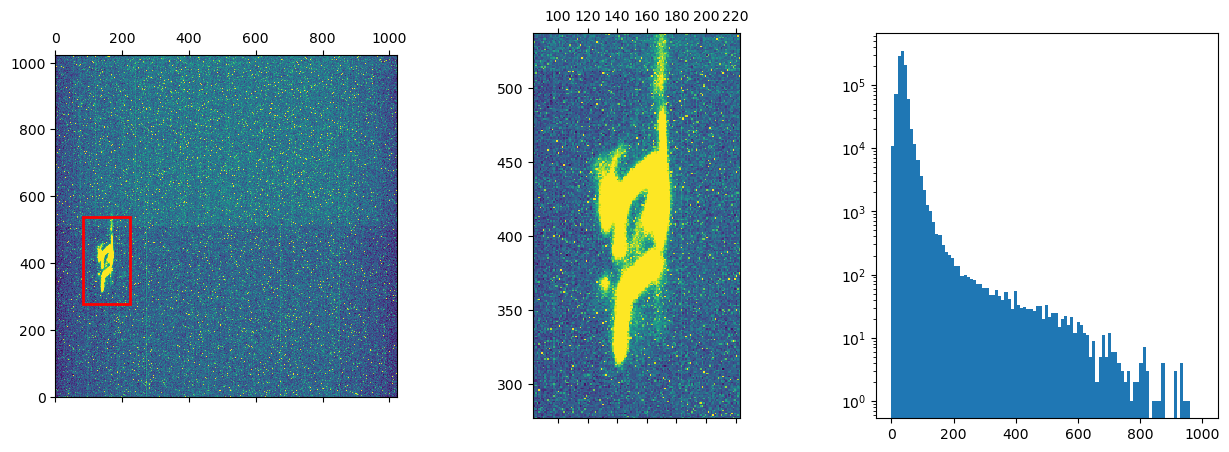

In [9]:
# Compare with and without background subtraction

xtpr.show_current_frame(
    vrange=(0,100),
    bins=np.linspace(0,1000,100),
    fov=fov,
    preprocess='bksb'
)
xtpr.show_current_frame(
    vrange=(0,100),
    bins=np.linspace(0,1000,100),
    fov=fov,
    preprocess=None
)

## Denoise image

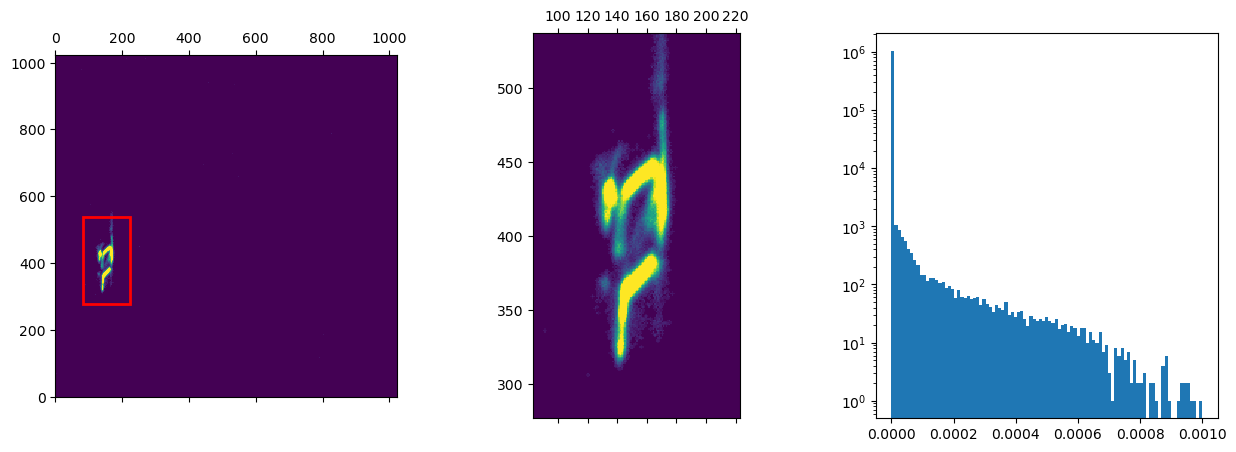

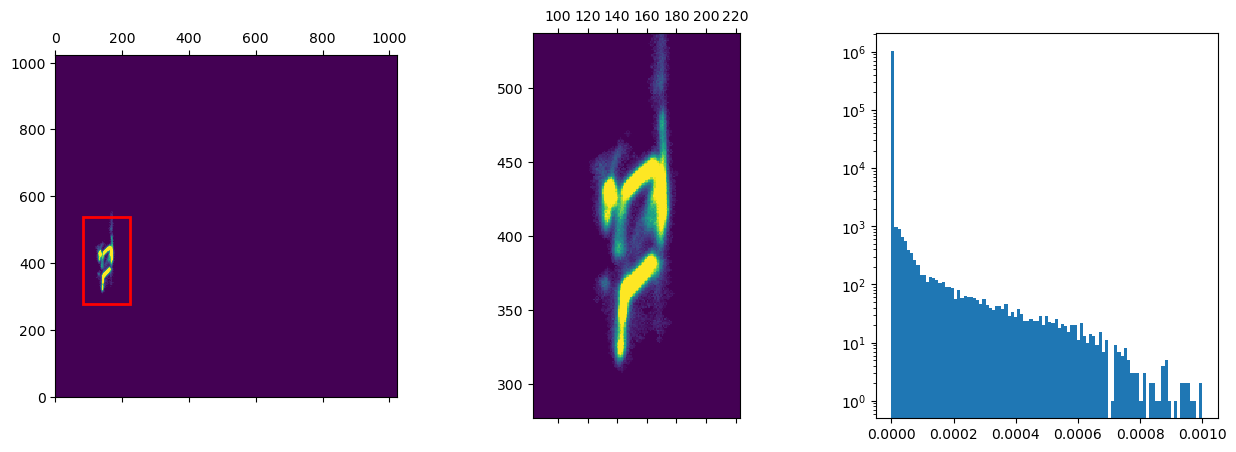

In [10]:
# Get and show background subtracted and denoised images

# ...with default denoising params
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(),
    vrange=(0,3e-4),
    bins=np.linspace(0,1e-3,100),
    fov=fov
)

# ...with tweaked denoising params
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(nstd=1,close=2),
    vrange=(0,3e-4),
    bins=np.linspace(0,1e-3,100),
    fov=fov
)

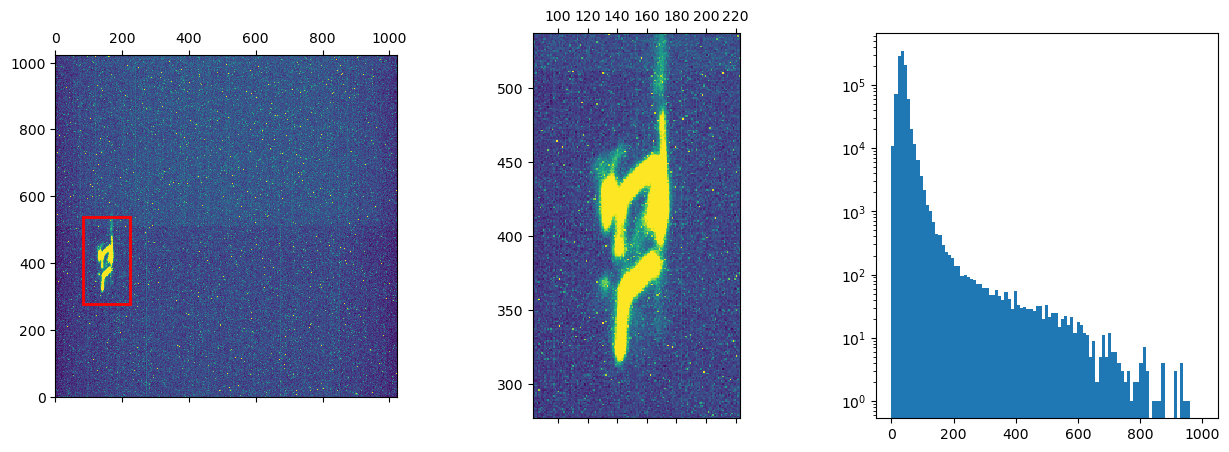

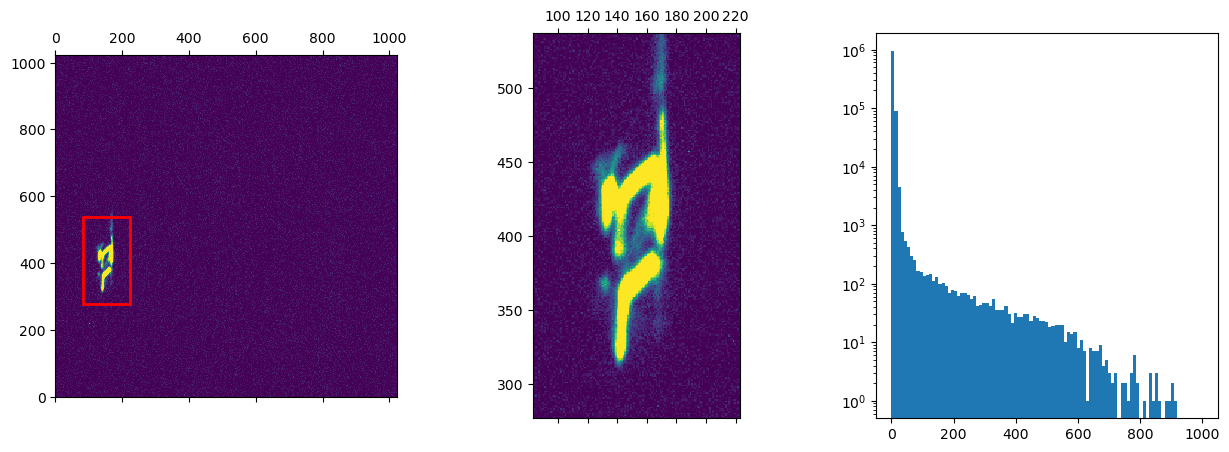

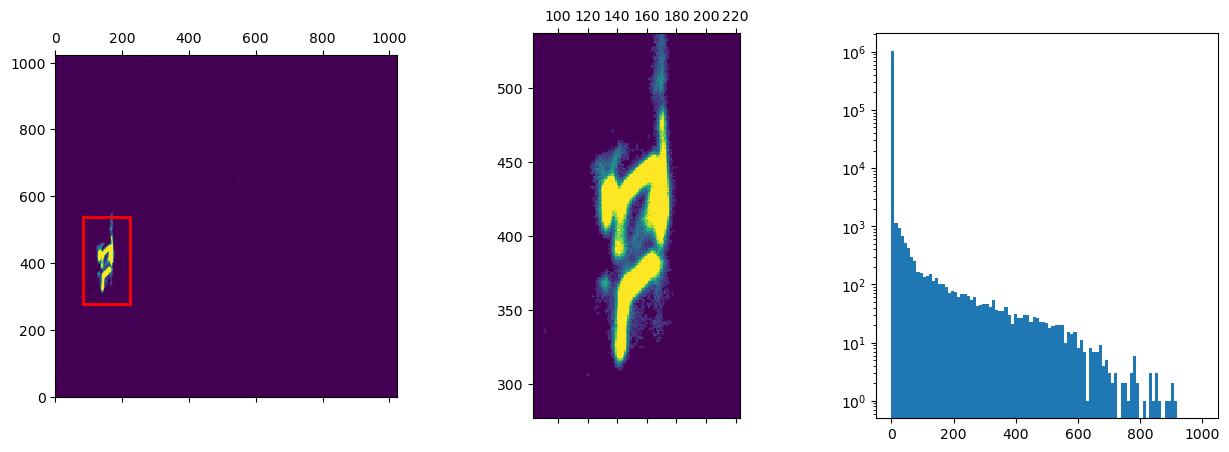

In [11]:
# Show raw / bksb / denoised

vmax = 150

xtpr.show_current_frame(
    vrange=(0,vmax),
    bins=np.linspace(0,1000,100),
    fov=fov,
)
xtpr.show_current_frame(
    vrange=(0,vmax),
    bins=np.linspace(0,1000,100),
    fov=fov,
    preprocess = 'bksb'
)
xtpr.show_current_frame(
    vrange=(0,vmax),
    bins=np.linspace(0,1000,100),
    fov=fov,
    preprocess='denoise_nonorm'
)

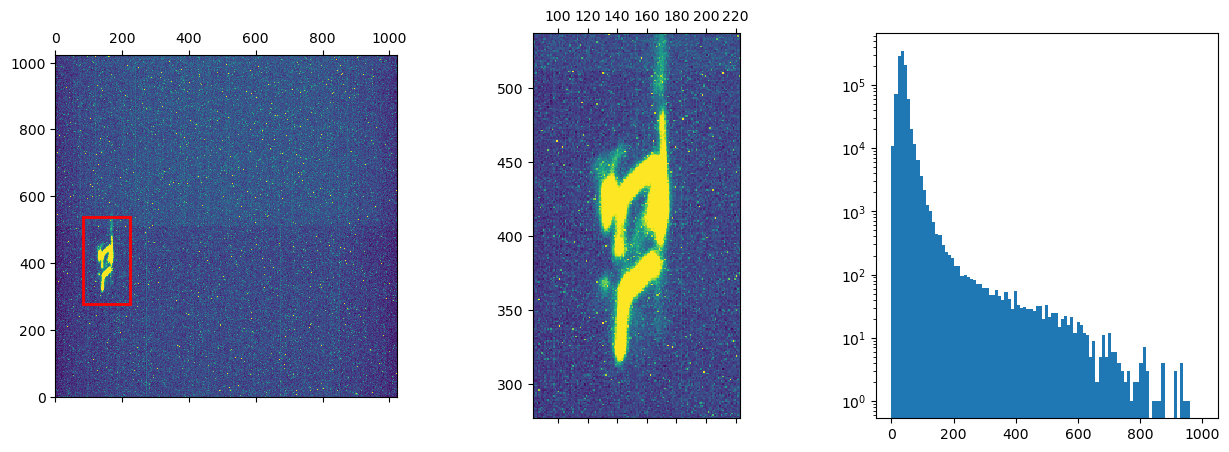

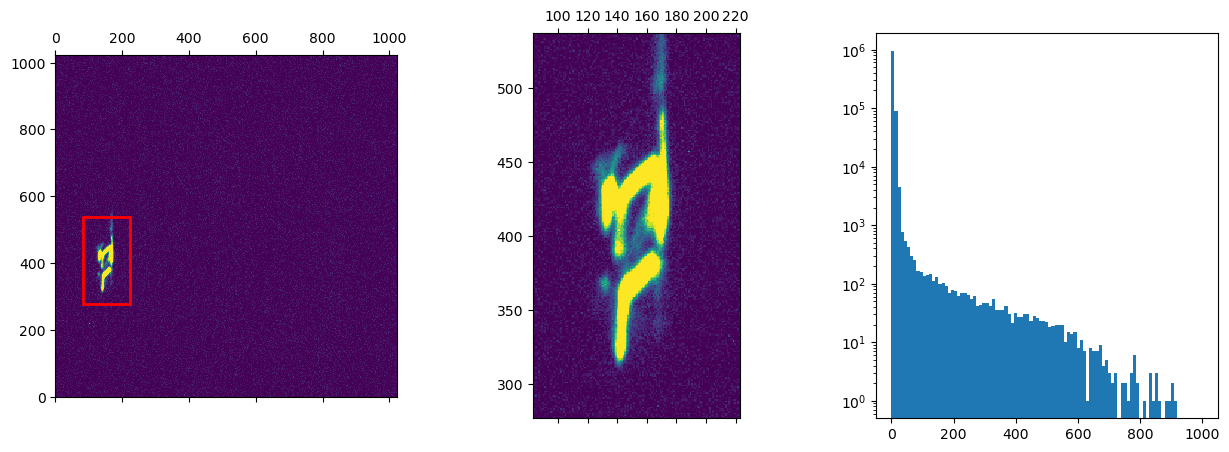

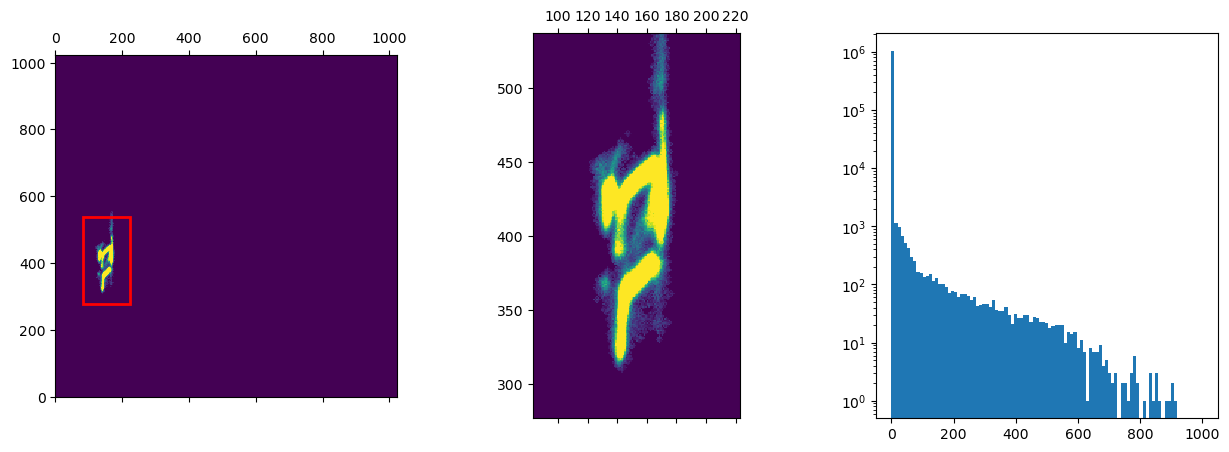

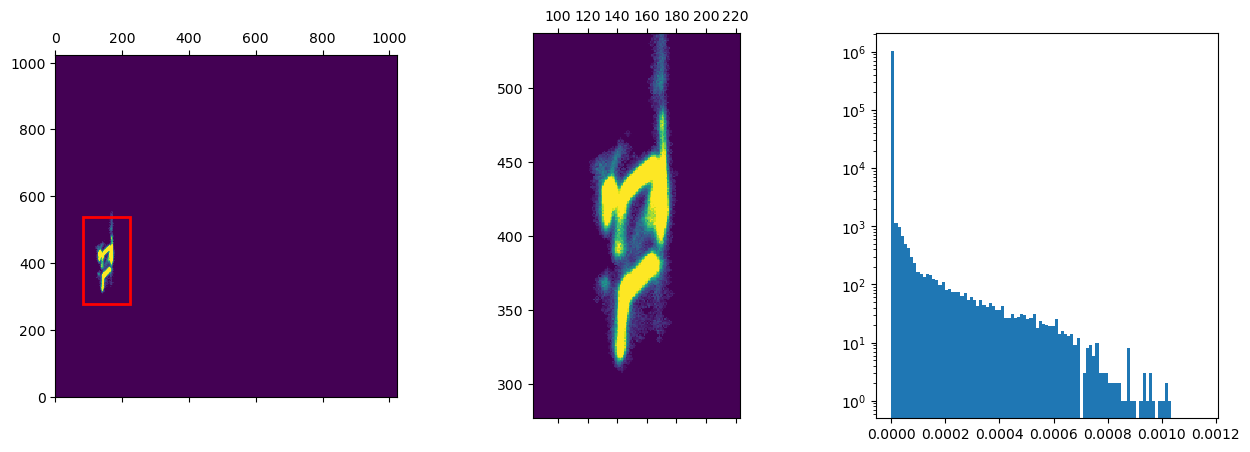

In [12]:
# Show raw / bksb / denoised / normalized

vmax = 150

xtpr.show_current_frame(
    vrange=(0,vmax),
    bins=np.linspace(0,1000,100),
    fov=fov,
)
xtpr.show_current_frame(
    vrange=(0,vmax),
    bins=np.linspace(0,1000,100),
    fov=fov,
    preprocess = 'bksb'
)
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(nstd=1,close=2,normalize=False),
    vrange=(0,vmax),
    bins=np.linspace(0,1000,100),
    fov=fov,
)
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(nstd=1,close=2),
    vrange=(0,2e-4),
    bins=np.linspace(0,1.15e-3,100),
    fov=fov,
)

## Show denoise statistics ROI

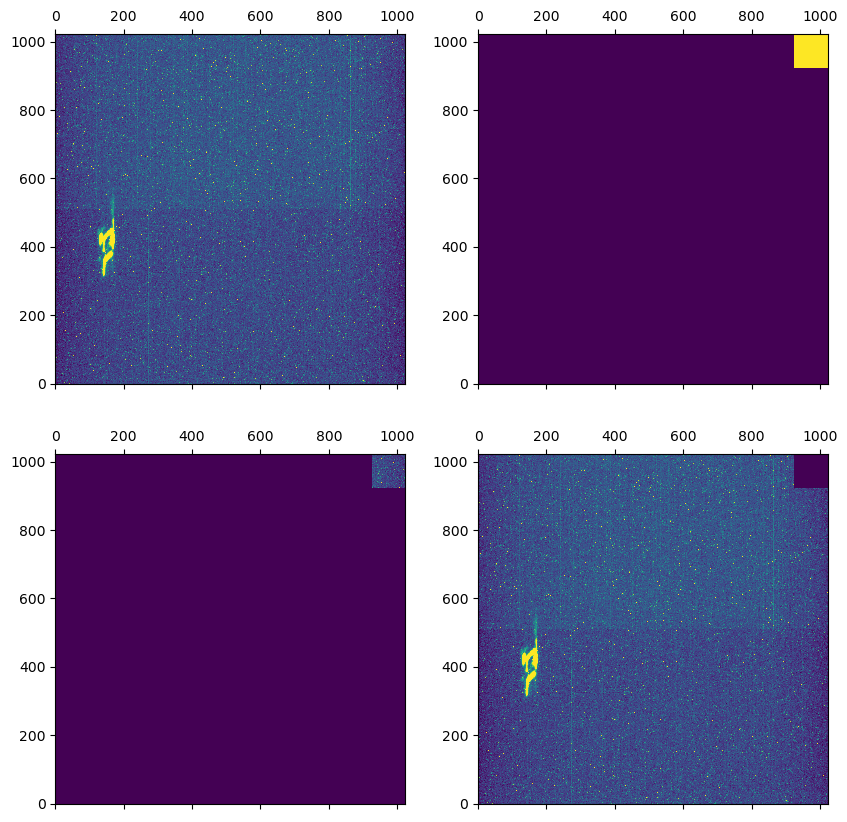

In [13]:
# Show selected ROI for noise statistics used in denoising algo

xtpr.show_denoise_statistics_ROI(vrange=(0,150))